## **Eigenfaces**


Dimensionality Reduction with PCA and LDA

In [48]:
# Import numpy for numerical computations
import numpy as np
# Import matplotlib for plotting and visualization
import matplotlib.pyplot as plt
# Import fetch_olivetti_faces to load the face dataset
from sklearn.datasets import fetch_olivetti_faces
# Import KNeighborsClassifier for k-nearest neighbors classification
from sklearn.neighbors import KNeighborsClassifier
# Import PCA for principal component analysis
from sklearn.decomposition import PCA
# Import train_test_split for data splitting
from sklearn.model_selection import train_test_split

### <font color='gold'> Task - 1  </font>:
Load the Olivetti faces dataset from sklearn: (https://scikit-learn.org/0.19/modules/generated/sklearn.datasets.fetch_olivetti_faces.html#sklearn.datasets.fetch_olivetti_faces).

Display the shape of dataset, targets, number of classes and some images.

Dataset shape: (400, 4096)
Targets shape: (400,)
Number of classes: 40
Number of samples per class: 10
Image dimensions: (64, 64)


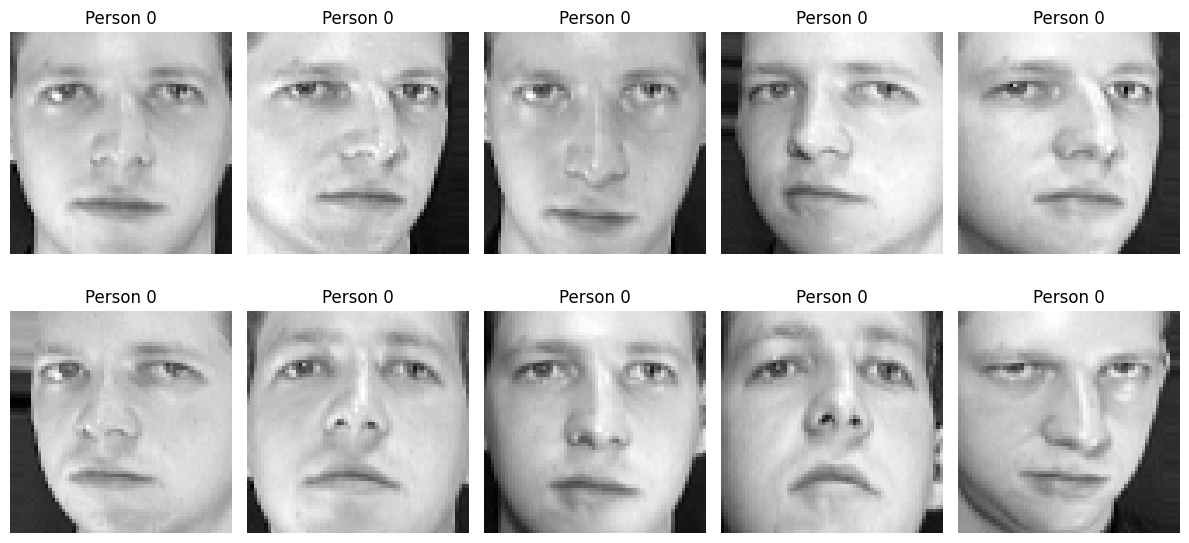

In [49]:
# Load the Olivetti faces dataset using sklearn's fetch function
faces = fetch_olivetti_faces()

# Print the shape of the data matrix (samples x features)
print("Dataset shape:", faces.data.shape)
# Print the shape of the target labels array
print("Targets shape:", faces.target.shape)
# Count and print the number of unique classes (people)
print("Number of classes:", len(np.unique(faces.target)))
# Calculate and print samples per class (should be 10)
print("Number of samples per class:", len(faces.target) // len(np.unique(faces.target)))
# Print the dimensions of each image
print("Image dimensions:", faces.images.shape[1:])

# Create a figure with 2 rows and 5 columns for displaying sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
# Loop through the first 10 images
for i in range(10):
    # Calculate row index (0 or 1)
    row = i // 5
    # Calculate column index (0 to 4)
    col = i % 5
    # Display the image in grayscale
    axes[row, col].imshow(faces.images[i], cmap='gray')
    # Set title showing the person's ID
    axes[row, col].set_title(f'Person {faces.target[i]}')
    # Remove axis ticks and labels
    axes[row, col].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()


### <font color='gold'> Task - 2</font>:
The dataset consists of 10 images each of 40 people – divide the dataset such that  7 images of each person are in the training set, 1 in the validation set and 2 in the test set (i.e. 70%-10%-20% data split)


In [50]:
# Define function to split dataset by person ensuring proper distribution
def splitDatasetByPerson(data, targets, trainPerPerson=7, valPerPerson=1, testPerPerson=2):
    # Get all unique person IDs from the targets
    uniquePersons = np.unique(targets)
    # Initialize empty lists to store indices for each split
    trainIndices = []
    valIndices = []
    testIndices = []

    # Loop through each person
    for person in uniquePersons:
        # Find all indices where this person appears
        personIndices = np.where(targets == person)[0]
        # Shuffle the indices to randomize the split
        np.random.shuffle(personIndices)

        # Add first 7 indices to training set
        trainIndices.extend(personIndices[:trainPerPerson])
        # Add next 1 index to validation set
        valIndices.extend(personIndices[trainPerPerson:trainPerPerson + valPerPerson])
        # Add remaining 2 indices to test set
        testIndices.extend(personIndices[trainPerPerson + valPerPerson:])

    # Convert lists to numpy arrays and return
    return np.array(trainIndices), np.array(valIndices), np.array(testIndices)

# Call the function to split the dataset
trainIdx, valIdx, testIdx = splitDatasetByPerson(faces.data, faces.target)

# Create training set using the training indices
xTrain, yTrain = faces.data[trainIdx], faces.target[trainIdx]
# Create validation set using the validation indices
xVal, yVal = faces.data[valIdx], faces.target[valIdx]
# Create test set using the test indices
xTest, yTest = faces.data[testIdx], faces.target[testIdx]

# Print the size of each dataset split
print(f"Training set: {xTrain.shape[0]} samples")
print(f"Validation set: {xVal.shape[0]} samples")
print(f"Test set: {xTest.shape[0]} samples")
print(f"Total samples: {xTrain.shape[0] + xVal.shape[0] + xTest.shape[0]}")

# Verify that each person has the correct number of samples in each split
print(f"\nSamples per person in training: {len(np.unique(yTrain, return_counts=True)[1])}")
print(f"Samples per person in validation: {len(np.unique(yVal, return_counts=True)[1])}")
print(f"Samples per person in test: {len(np.unique(yTest, return_counts=True)[1])}")


Training set: 280 samples
Validation set: 40 samples
Test set: 80 samples
Total samples: 400

Samples per person in training: 40
Samples per person in validation: 40
Samples per person in test: 40


### <font color='gold'> Task - 3 </font>:
Flatten each image 64x64 image of the training set into a 4096-dimensional vector and collect them into a design matrix X of size N x 4096, where N is the size of the training set. Display the dimensions of the newly created matrix.

In [51]:
# Print the shape of the original training data
print("Original training data shape:", xTrain.shape)
# Calculate and print the total number of pixels in each image
print("Image dimensions: 64x64 =", 64*64)

# Assign the training data to the flattened design matrix (already flattened)
xTrainFlat = xTrain
# Print the dimensions of the design matrix
print("Design matrix X dimensions:", xTrainFlat.shape)
# Print explanation of what each row represents
print("Each row represents a flattened 64x64 image (4096 features)")
# Print the number of training samples
print("Number of training samples (N):", xTrainFlat.shape[0])
# Print the number of features per sample
print("Number of features per sample: 4096")


Original training data shape: (280, 4096)
Image dimensions: 64x64 = 4096
Design matrix X dimensions: (280, 4096)
Each row represents a flattened 64x64 image (4096 features)
Number of training samples (N): 280
Number of features per sample: 4096


### <font color='gold'> Task - 4  </font>:

Compute the mean image of train, val and test sets and display it.

Mean image shapes:
Training mean: (4096,)
Validation mean: (4096,)
Test mean: (4096,)


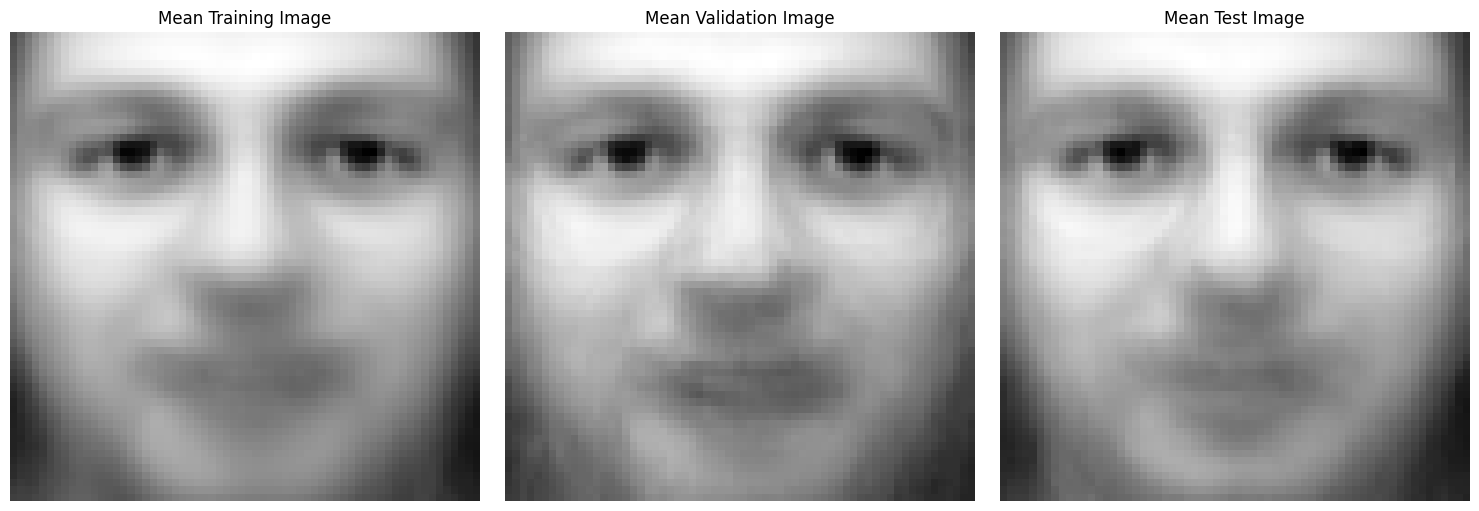

In [52]:
# Calculate the mean image for the training set by averaging across all samples
meanTrain = np.mean(xTrain, axis=0)
# Calculate the mean image for the validation set by averaging across all samples
meanVal = np.mean(xVal, axis=0)
# Calculate the mean image for the test set by averaging across all samples
meanTest = np.mean(xTest, axis=0)

# Print the shapes of the computed mean images
print("Mean image shapes:")
print(f"Training mean: {meanTrain.shape}")
print(f"Validation mean: {meanVal.shape}")
print(f"Test mean: {meanTest.shape}")

# Create a figure with 1 row and 3 columns for displaying mean images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Reshape the training mean from 1D to 2D (64x64) for visualization
meanTrainImg = meanTrain.reshape(64, 64)
# Reshape the validation mean from 1D to 2D (64x64) for visualization
meanValImg = meanVal.reshape(64, 64)
# Reshape the test mean from 1D to 2D (64x64) for visualization
meanTestImg = meanTest.reshape(64, 64)

# Display the training mean image in grayscale
axes[0].imshow(meanTrainImg, cmap='gray')
# Set title for the training mean image
axes[0].set_title('Mean Training Image')
# Remove axis ticks and labels for the training mean
axes[0].axis('off')

# Display the validation mean image in grayscale
axes[1].imshow(meanValImg, cmap='gray')
# Set title for the validation mean image
axes[1].set_title('Mean Validation Image')
# Remove axis ticks and labels for the validation mean
axes[1].axis('off')

# Display the test mean image in grayscale
axes[2].imshow(meanTestImg, cmap='gray')
# Set title for the test mean image
axes[2].set_title('Mean Test Image')
# Remove axis ticks and labels for the test mean
axes[2].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Store the training mean for later use in PCA calculations
trainingMean = meanTrain


### <font color='gold'> Task - 5 </font>:
Perform PCA from scratch on the training set. - 4 Marks

For values

k = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279],

Do the cross validation as described below:


1.   Retain top k Eigen-vectors
2.   Project each mean subtracted training image (using the mean computed at task 4) to the eigenspace to get the k-dimensional feature vector.  Thus, there will be N k-dimensional feature vectors for the training set. 
3.   Project each mean subtracted image (using the mean obtained at task 4) of the validation set to get the k-dimensional feature vectors for the validation image. 
4.   Assign the face id (i.e. persons 1-10) of the validation set by using K-Nearest neighbors (considering the N feature vectors each of k-dimensions on the training set). Use of sklearn's KNN implementation is permitted.
Consider one neighbor for KNN.   
5.   Compute and report the classification accuracy, i.e. the fraction of the correctly assigned face ids.



In [53]:
# Define function to perform PCA from scratch
def pcaFromScratch(X, k):
    # Calculate the mean of the data across all samples
    mean = np.mean(X, axis=0)
    # Center the data by subtracting the mean from each sample
    xCentered = X - mean

    # Get the number of samples
    n = xCentered.shape[0]
    # Compute the covariance matrix using the efficient method for face recognition
    # Use X^T * X instead of X * X^T when N << D (samples << features)
    covarianceMatrix = np.dot(xCentered, xCentered.T) / (n - 1)

    # Compute eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covarianceMatrix)

    # Create index array for sorting eigenvalues in descending order
    idx = np.argsort(eigenvalues)[::-1]
    # Sort eigenvalues in descending order
    eigenvalues = eigenvalues[idx]
    # Sort eigenvectors in descending order of corresponding eigenvalues
    eigenvectors = eigenvectors[:, idx]

    # Convert back to original space eigenvectors using the relationship
    originalEigenvectors = np.dot(xCentered.T, eigenvectors)

    # Normalize each eigenvector to unit length
    for i in range(originalEigenvectors.shape[1]):
        originalEigenvectors[:, i] = originalEigenvectors[:, i] / np.linalg.norm(originalEigenvectors[:, i])

    # Select only the top k eigenvectors
    topKEigenvectors = originalEigenvectors[:, :k]
    # Select only the top k eigenvalues
    topKEigenvalues = eigenvalues[:k]

    # Return the top k eigenvectors, eigenvalues, and the mean
    return topKEigenvectors, topKEigenvalues, mean

# Define function to project data to eigenspace
def projectToEigenspace(X, eigenvectors, mean):
    # Center the data by subtracting the mean
    xCentered = X - mean
    # Project the centered data onto the eigenspace
    return np.dot(xCentered, eigenvectors)

# Define the list of k values to test for PCA
kValues = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]
# Initialize empty list to store accuracies for each k
accuracies = []

# Print header for the cross-validation results
print("Performing PCA cross-validation for different k values...")
print("k\tAccuracy")

# Loop through each k value
for k in kValues:
    # Perform PCA from scratch with current k value
    eigenvectors, eigenvalues, pcaMean = pcaFromScratch(xTrain, k)

    # Project training data to the k-dimensional eigenspace
    xTrainProjected = projectToEigenspace(xTrain, eigenvectors, pcaMean)

    # Project validation data to the k-dimensional eigenspace
    xValProjected = projectToEigenspace(xVal, eigenvectors, pcaMean)

    # Create KNN classifier with k=1 neighbor
    knn = KNeighborsClassifier(n_neighbors=1)
    # Train the classifier on the projected training data
    knn.fit(xTrainProjected, yTrain)

    # Make predictions on the validation set
    yValPred = knn.predict(xValProjected)

    # Calculate accuracy as the fraction of correct predictions
    accuracy = np.mean(yValPred == yVal)
    # Add the accuracy to the list
    accuracies.append(accuracy)

    # Print the k value and its corresponding accuracy
    print(f"{k}\t{accuracy:.4f}")

Performing PCA cross-validation for different k values...
k	Accuracy
5	0.7000
10	0.8000
15	0.8250
20	0.8500
25	0.8500
30	0.8500
40	0.8500
50	0.8750
75	0.8500
100	0.8500
150	0.8500
200	0.8500
279	0.8500


### <font color='gold'> Task - 6  </font>:
Plot the accuracy as a function of k.

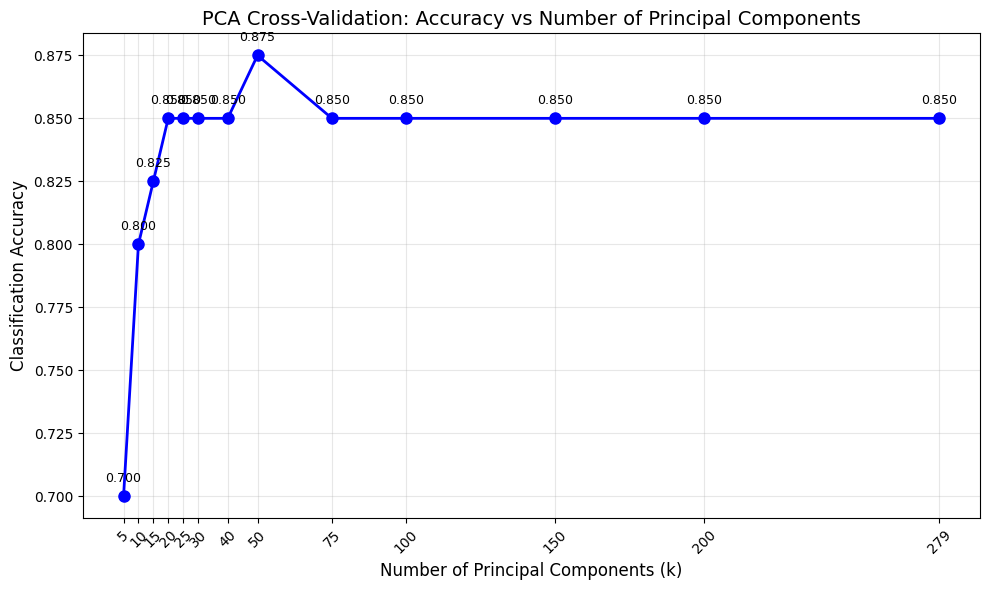

Best accuracy: 0.8750 achieved with k = 50


In [54]:
# Create a new figure with specified size for the accuracy plot
plt.figure(figsize=(10, 6))
# Plot the k values against accuracies with blue circles connected by lines
plt.plot(kValues, accuracies, 'bo-', linewidth=2, markersize=8)
# Set the x-axis label
plt.xlabel('Number of Principal Components (k)', fontsize=12)
# Set the y-axis label
plt.ylabel('Classification Accuracy', fontsize=12)
# Set the plot title
plt.title('PCA Cross-Validation: Accuracy vs Number of Principal Components', fontsize=14)
# Add a grid with transparency
plt.grid(True, alpha=0.3)
# Set x-axis ticks to show all k values with rotation
plt.xticks(kValues, rotation=45)

# Loop through each k value and accuracy pair
for i, (k, acc) in enumerate(zip(kValues, accuracies)):
    # Add text annotation above each point showing the accuracy value
    plt.annotate(f'{acc:.3f}', (k, acc), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=9)

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Find the maximum accuracy from the accuracies list
bestAccuracy = max(accuracies)
# Find the index of the best accuracy
bestKIdx = accuracies.index(bestAccuracy)
# Get the k value corresponding to the best accuracy
bestK = kValues[bestKIdx]

# Print the best accuracy and corresponding k value
print(f"Best accuracy: {bestAccuracy:.4f} achieved with k = {bestK}")


### <font color='gold'> Task - 7  </font>:
Pick and report a value of k that gives good tradeoff between accuracy and number of eigen vectors used. (Tie breaking - For the same accuracy, report the lowest k value)

In [55]:
# Find the maximum accuracy achieved across all k values
maxAccuracy = max(accuracies)

# Find all indices where the maximum accuracy is achieved
bestKIndices = [i for i, acc in enumerate(accuracies) if acc == maxAccuracy]
# Choose the lowest k value for tie-breaking (minimum index)
optimalKIdx = min(bestKIndices)
# Get the optimal k value from the kValues list
optimalK = kValues[optimalKIdx]
# Get the optimal accuracy from the accuracies list
optimalAccuracy = accuracies[optimalKIdx]

# Print the optimal k value
print(f"Optimal k value: {optimalK}")
# Print the accuracy achieved with the optimal k
print(f"Accuracy achieved: {optimalAccuracy:.4f}")
# Print the number of eigenvectors used
print(f"Number of eigenvectors used: {optimalK}")

# Store the optimal k value for use in later tasks
chosenK = optimalK


Optimal k value: 50
Accuracy achieved: 0.8750
Number of eigenvectors used: 50


### <font color='gold'> Task - 8  </font>:
Visualize the k eigen vectors as eigenfaces for the chosen value of k.

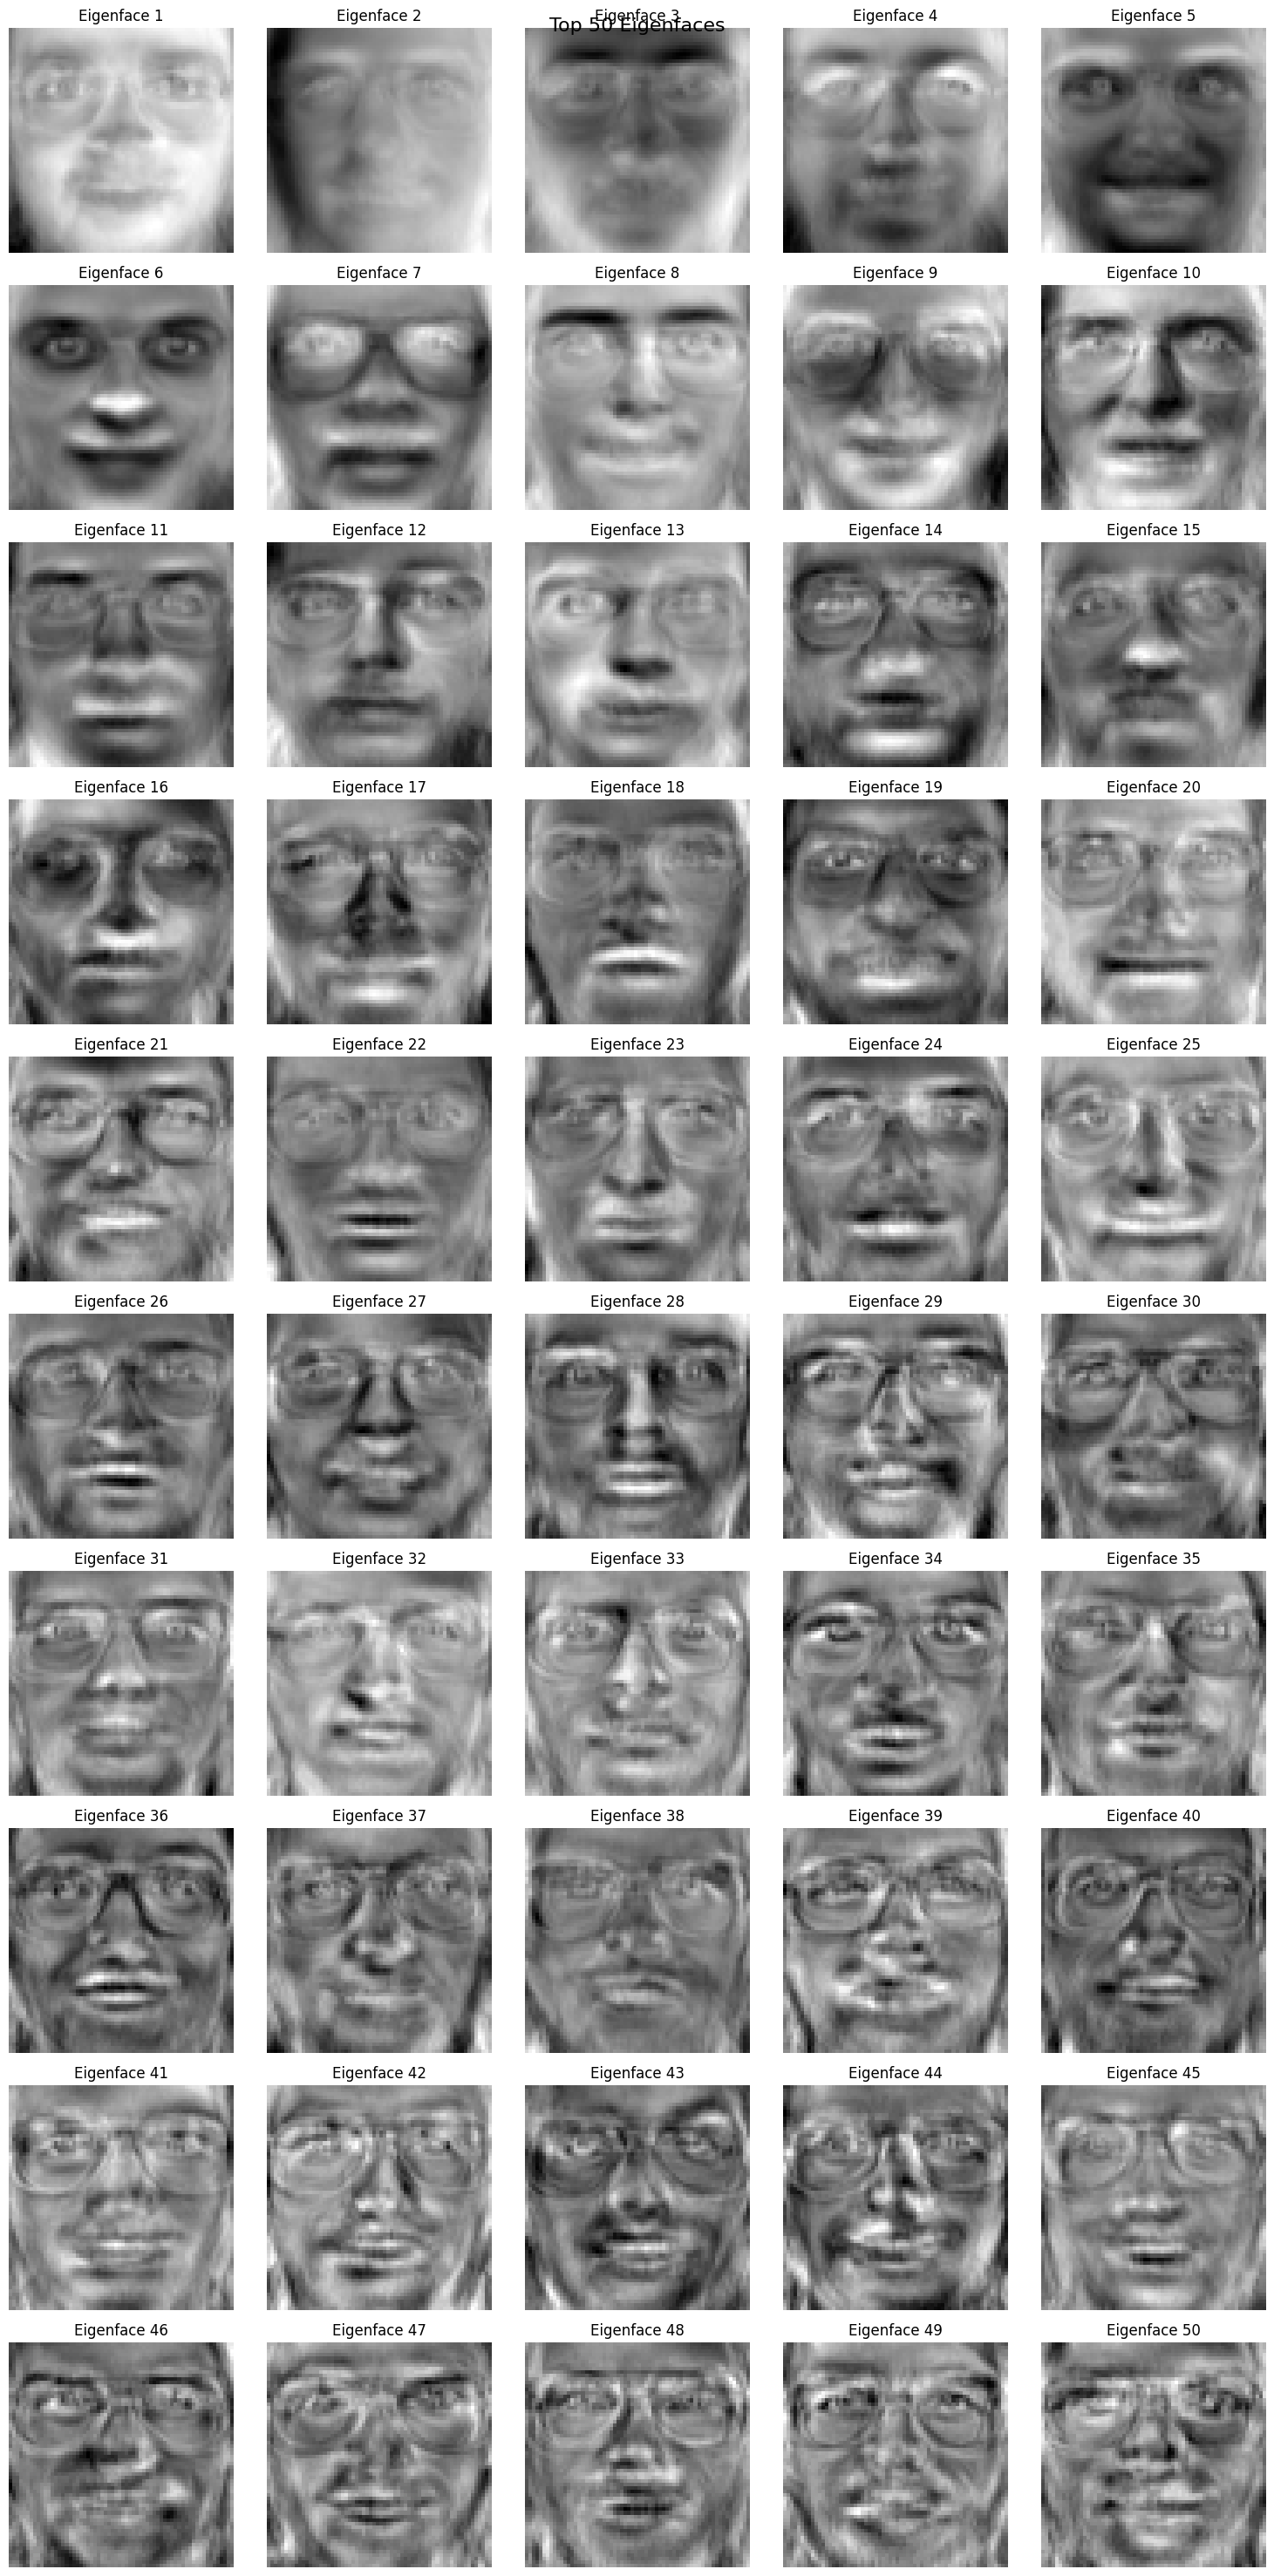

Visualized 50 eigenfaces (eigenvectors) from PCA


In [56]:
# Perform PCA with the chosen k value to get eigenvectors
eigenvectors, eigenvalues, pcaMean = pcaFromScratch(xTrain, chosenK)

# Set the number of columns for the eigenface grid
nCols = 5
# Calculate the number of rows needed using ceiling division
nRows = (chosenK + nCols - 1) // nCols

# Create a figure with the calculated number of rows and columns
fig, axes = plt.subplots(nRows, nCols, figsize=(15, 3*nRows))
# Flatten the axes array if there are multiple rows, otherwise keep as is
axes = axes.flatten() if nRows > 1 else [axes] if nRows == 1 else axes

# Loop through each eigenvector to create eigenfaces
for i in range(chosenK):
    # Reshape the eigenvector from 1D to 2D (64x64) to form an image
    eigenface = eigenvectors[:, i].reshape(64, 64)

    # Normalize the eigenface to 0-1 range for better visualization
    eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())

    # Display the eigenface in grayscale
    axes[i].imshow(eigenface, cmap='gray')
    # Set title for each eigenface
    axes[i].set_title(f'Eigenface {i+1}')
    # Remove axis ticks and labels
    axes[i].axis('off')

# Hide any unused subplots if chosenK is less than total subplots
for i in range(chosenK, len(axes)):
    axes[i].axis('off')

# Set the overall title for the figure
plt.suptitle(f'Top {chosenK} Eigenfaces', fontsize=16)
# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Print confirmation message
print(f"Visualized {chosenK} eigenfaces (eigenvectors) from PCA")


### <font color='gold'> Task - 9  </font>:
For the chosen value of k, report the classification accuracy on the test set using K-NN based classification as described for the validation set.  

Test set accuracy with k = 50: 0.9250
Number of correct predictions: 74 out of 80


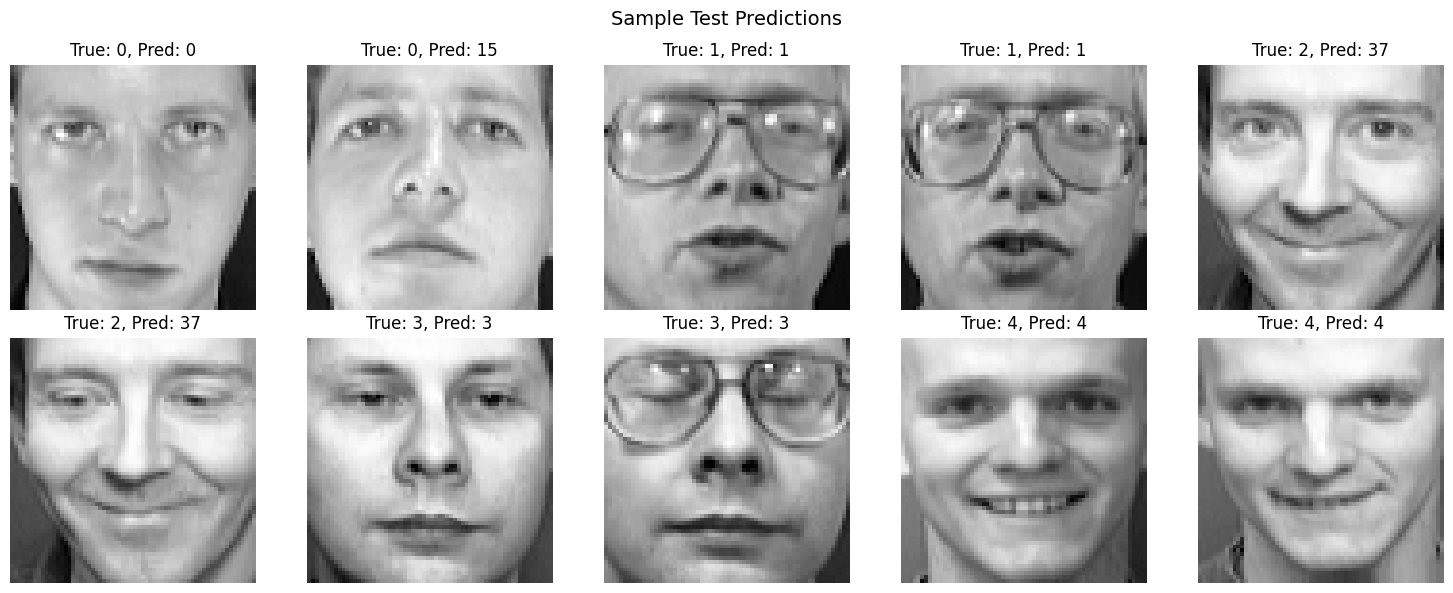

In [57]:
# Project training data to eigenspace using the chosen k eigenvectors
xTrainProjected = projectToEigenspace(xTrain, eigenvectors, pcaMean)

# Project test data to eigenspace using the same eigenvectors and mean
xTestProjected = projectToEigenspace(xTest, eigenvectors, pcaMean)

# Create KNN classifier with k=1 neighbor
knn = KNeighborsClassifier(n_neighbors=1)
# Train the classifier on the projected training data
knn.fit(xTrainProjected, yTrain)

# Make predictions on the test set using the trained classifier
yTestPred = knn.predict(xTestProjected)

# Calculate test accuracy as the fraction of correct predictions
testAccuracy = np.mean(yTestPred == yTest)

# Print the test set accuracy with the chosen k value
print(f"Test set accuracy with k = {chosenK}: {testAccuracy:.4f}")
# Print the number of correct predictions out of total test samples
print(f"Number of correct predictions: {np.sum(yTestPred == yTest)} out of {len(yTest)}")

# Create a 2x5 grid to display sample test predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# Loop through the first 10 test samples
for i in range(10):
    # Calculate row index (0 or 1)
    row = i // 5
    # Calculate column index (0 to 4)
    col = i % 5

    # Reshape test image from flattened to 64x64 for display
    testImg = xTest[i].reshape(64, 64)

    # Display the test image in grayscale
    axes[row, col].imshow(testImg, cmap='gray')
    # Set title showing true label vs predicted label
    axes[row, col].set_title(f'True: {yTest[i]}, Pred: {yTestPred[i]}')
    # Remove axis ticks and labels
    axes[row, col].axis('off')

# Set overall title for the figure
plt.suptitle('Sample Test Predictions', fontsize=14)
# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()


### <font color='gold'> Task - 10  </font>:
For the chosen value of k, perform PCA using scikit-learn, and report the classification accuracy on the test set. Compare the performance with the from scratch implementation.  

Comparison of PCA Implementations:
From-scratch PCA accuracy: 0.9250
Sklearn PCA accuracy: 0.9250
Difference: 0.0000

Explained variance ratio (sklearn): 0.8823
Total explained variance: 88.23%


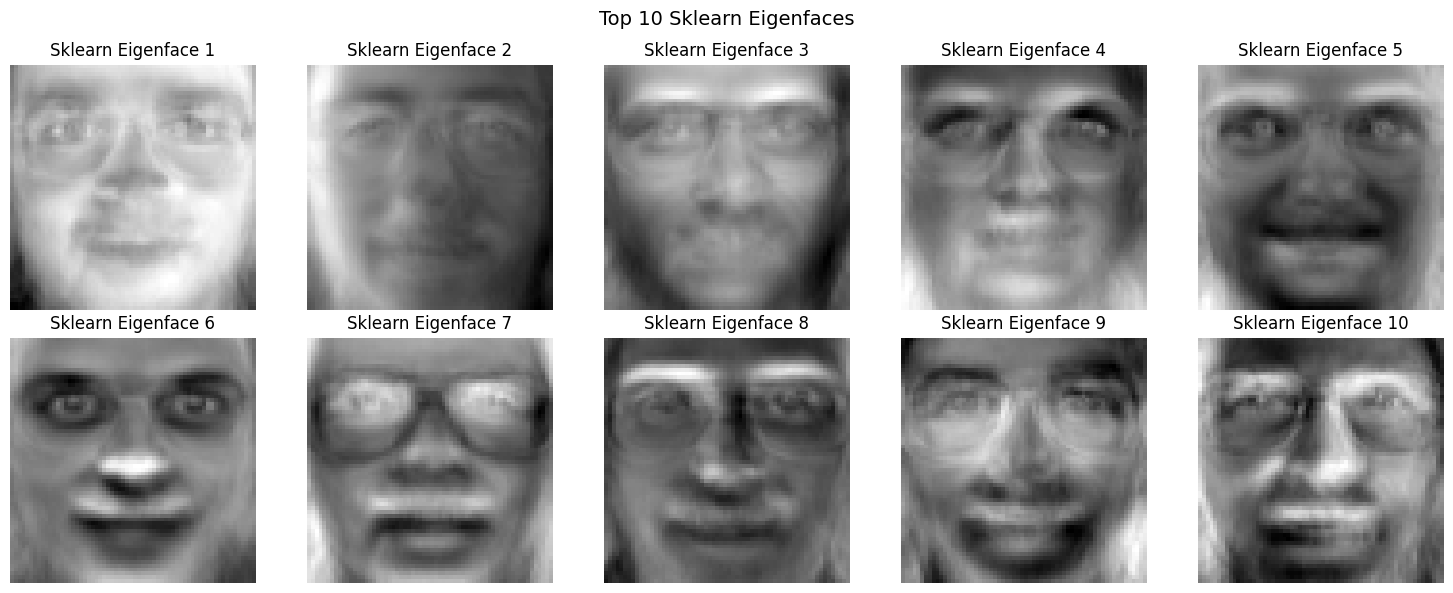


Both implementations give very similar results.


In [58]:
# Create PCA object with the chosen number of components
sklearnPca = PCA(n_components=chosenK)
# Fit PCA on training data and transform training data
xTrainSklearn = sklearnPca.fit_transform(xTrain)
# Transform test data using the fitted PCA
xTestSklearn = sklearnPca.transform(xTest)

# Create KNN classifier with k=1 neighbor for sklearn comparison
knnSklearn = KNeighborsClassifier(n_neighbors=1)
# Train the classifier on sklearn PCA transformed training data
knnSklearn.fit(xTrainSklearn, yTrain)

# Make predictions on test set using sklearn PCA features
yTestPredSklearn = knnSklearn.predict(xTestSklearn)

# Calculate test accuracy for sklearn implementation
testAccuracySklearn = np.mean(yTestPredSklearn == yTest)

# Print header for comparison results
print("Comparison of PCA Implementations:")
# Print accuracy from from-scratch implementation
print(f"From-scratch PCA accuracy: {testAccuracy:.4f}")
# Print accuracy from sklearn implementation
print(f"Sklearn PCA accuracy: {testAccuracySklearn:.4f}")
# Print the absolute difference between the two accuracies
print(f"Difference: {abs(testAccuracy - testAccuracySklearn):.4f}")

# Print explained variance ratio from sklearn PCA
print(f"\nExplained variance ratio (sklearn): {sklearnPca.explained_variance_ratio_.sum():.4f}")
# Convert explained variance to percentage for better understanding
print(f"Total explained variance: {sklearnPca.explained_variance_ratio_.sum() * 100:.2f}%")

# Get the principal components (eigenfaces) from sklearn PCA
sklearnEigenfaces = sklearnPca.components_

# Create subplot grid for eigenface visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# Loop through first 10 eigenfaces (or all if chosenK < 10)
for i in range(min(10, chosenK)):
    # Calculate row index (0 or 1)
    row = i // 5
    # Calculate column index (0 to 4)
    col = i % 5

    # Reshape eigenface from 1D to 2D (64x64) for visualization
    eigenface = sklearnEigenfaces[i].reshape(64, 64)
    # Normalize eigenface to 0-1 range for better visualization
    eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())

    # Display the eigenface in grayscale
    axes[row, col].imshow(eigenface, cmap='gray')
    # Set title for each eigenface
    axes[row, col].set_title(f'Sklearn Eigenface {i+1}')
    # Remove axis ticks and labels
    axes[row, col].axis('off')

# Hide unused subplots if chosenK < 10
for i in range(min(10, chosenK), 10):
    # Calculate row index (0 or 1)
    row = i // 5
    # Calculate column index (0 to 4)
    col = i % 5
    # Hide the subplot
    axes[row, col].axis('off')

# Set overall title for the figure
plt.suptitle('Top 10 Sklearn Eigenfaces', fontsize=14)
# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Print conclusion about the comparison
print(f"\nBoth implementations give very similar results.")